# Startup Investment Outcome — Feature Selection & Modeling (Binary Classification)

**Configuration:** Set `PROBLEM = "closed"` or `"acquired"` in the **Config cell** below (same value you used in `06_Imbalanced_Data_Handling_Binary.ipynb`).

**Input:** `data/train_resampled_closed.csv` or `data/train_resampled_acquired.csv` (from notebook 06), `data/val_processed.csv`, `data/test_processed.csv`  
**Goal:** Select the most informative features and train multiple binary classifiers, selecting the best model for final evaluation on the test set.  
**Note:** All feature selection is fit on the **training set only**. Validation and test sets are transformed, never used to fit selectors.

Each section ends with a **→ Modeling Decision** box.

**Pipeline position:**
```
01_EDA → 02_... → 03_Preprocessing → 04_Imbalanced_Data → 06_Binary_Imbalanced → [07_Binary_Modeling] ← you are here
```

## 0. Imports & Setup

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Must match the PROBLEM setting used in 06_Imbalanced_Data_Handling_Binary.ipynb
#   "closed"   → load train_resampled_closed.csv
#   "acquired" → load train_resampled_acquired.csv

PROBLEM = "closed"   # <── change this

if PROBLEM == "closed":
    TARGET_CLASS_CODE = 0
    STATUS_MAP        = {0: 'not_closed', 1: 'closed'}
    STATUS_NAMES      = ['not_closed', 'closed']
    RESAMPLED_OUT     = "data/train_resampled_closed.csv"
elif PROBLEM == "acquired":
    TARGET_CLASS_CODE = 2
    STATUS_MAP        = {0: 'not_acquired', 1: 'acquired'}
    STATUS_NAMES      = ['not_acquired', 'acquired']
    RESAMPLED_OUT     = "data/train_resampled_acquired.csv"
else:
    raise ValueError(f"PROBLEM must be 'closed' or 'acquired', got: '{PROBLEM}'")

# Metric used to select the best model (Sections 9, 12)
# Valid choices — must be a column name returned by classification_metrics():
#   'Macro F1'              — equal weight to both classes (recommended default)
#   'Weighted F1'           — weight by class frequency
#   'Accuracy'              — raw accuracy
#   f'F1 {STATUS_NAMES[1]}' — F1 of the positive (minority) class only
EVAL_METRIC = 'F1 closed'   # <── change this

print(f"Problem      : {PROBLEM}")
print(f"Target class : {TARGET_CLASS_CODE}  ({STATUS_NAMES[1]})")
print(f"Class names  : {STATUS_NAMES}")
print(f"Input file   : {RESAMPLED_OUT}")
print(f"Eval metric  : {EVAL_METRIC}")

Problem      : closed
Target class : 0  (closed)
Class names  : ['not_closed', 'closed']
Input file   : data/train_resampled_closed.csv
Eval metric  : F1 closed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Feature selection
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2,
    SelectFromModel, SequentialFeatureSelector
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Evaluation
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, roc_curve, auc, classification_report
)

# Permutation importance
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

# STATUS_MAP, STATUS_NAMES are set in the Config cell above
COLORS       = ['#FF5722', '#2196F3']
RANDOM_STATE = 42

train = pd.read_csv(RESAMPLED_OUT)
val   = pd.read_csv('data/val_processed.csv')
test  = pd.read_csv('data/test_processed.csv')

# val/test come from 03_Preprocessing with status_code; create binary target
for df in [val, test]:
    df['status_binary'] = (df['status_code'] == TARGET_CLASS_CODE).astype(int)

# ── Drop columns not used for modeling ────────────────────────────────────
RAW_FUNDING_COLS = [
    'funding_total_usd', 'seed', 'venture', 'angel', 'grant',
    'private_equity', 'debt_financing', 'equity_crowdfunding',
    'convertible_note', 'undisclosed', 'product_crowdfunding',
    'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
]
RAW_ROUND_COLS = ['round_A', 'round_B', 'round_C', 'round_D_plus']
DROP_COLS = ['status_code', 'status_binary', 'geo_cluster'] + RAW_FUNDING_COLS + RAW_ROUND_COLS

def prepare_X(df):
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    return df.drop(columns=cols_to_drop)

X_train = prepare_X(train)
y_train = train['status_binary']

X_val   = prepare_X(val)
y_val   = val['status_binary']

X_test  = prepare_X(test)
y_test  = test['status_binary']

log_cols          = [c for c in X_train.columns if c.startswith('log_')]
raw_still_present = [c for c in RAW_FUNDING_COLS + RAW_ROUND_COLS if c in X_train.columns]
print(f"Train (resampled): {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"\nLog-transformed features ({len(log_cols)}): {log_cols}")
print(f"Raw cols remaining (should be 0): {raw_still_present}")
print(f"\nAll features ({len(X_train.columns)}): {list(X_train.columns)}")
print(f"\nClass distribution (train):")
for k, cnt in y_train.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>12s}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")

In [3]:
train = pd.read_csv('data/train_resampled_closed.csv')
val   = pd.read_csv('data/val_processed.csv')
test  = pd.read_csv('data/test_processed.csv')

# ── Drop columns not used for modeling ────────────────────────────────────
# geo_cluster: non-numeric cluster label (kept for EDA reference in 03_Preprocessing)
# Raw funding columns: 03_Preprocessing applies log1p via FundingLogTransformer,
# producing log_<col> versions. The originals are left in the CSV but must NOT
# be fed to the model — using both raw + log would introduce redundancy and
# let the model bypass the intended transformation.
RAW_FUNDING_COLS = [
    'funding_total_usd', 'seed', 'venture', 'angel', 'grant',
    'private_equity', 'debt_financing', 'equity_crowdfunding',
    'convertible_note', 'undisclosed', 'product_crowdfunding',
    'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
]

# Raw round amount columns: 03_Preprocessing logs these via FundingLogTransformer
# (round_A/B/C) and RoundBinarizer (round_D_plus → log_round_D_plus).
# Keep only the log_ versions; drop the originals to stay consistent with funding cols.
RAW_ROUND_COLS = ['round_A', 'round_B', 'round_C', 'round_D_plus']

DROP_COLS = ['status_code', 'geo_cluster'] + RAW_FUNDING_COLS + RAW_ROUND_COLS

def prepare_X(df):
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    return df.drop(columns=cols_to_drop)

X_train = prepare_X(train)
y_train = train['status_code']

X_val   = prepare_X(val)
y_val   = val['status_code']

X_test  = prepare_X(test)
y_test  = test['status_code']

# Verify log_ columns are present and raw columns are gone
log_cols          = [c for c in X_train.columns if c.startswith('log_')]
raw_still_present = [c for c in RAW_FUNDING_COLS + RAW_ROUND_COLS if c in X_train.columns]
print(f"Train (resampled): {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"\nLog-transformed features ({len(log_cols)}): {log_cols}")
print(f"Raw cols remaining (should be 0): {raw_still_present}")
print(f"\nAll features ({len(X_train.columns)}):")
print(list(X_train.columns))
print(f"\nClass distribution (train):")
for k, cnt in y_train.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>10s}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")

Train (resampled): (52700, 32)  |  Val: (5971, 32)  |  Test: (5971, 32)

Log-transformed features (18): ['log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market', 'log_round_A', 'log_round_B', 'log_round_C', 'log_round_D_plus']
Raw cols remaining (should be 0): []

All features (32):
['funding_rounds', 'founded_year', 'founded_month', 'founded_quarter', 'log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market', 'log_round_A', 'log_round_B', 'log_round_C', 'has_round_A', 'has_round_B', 'has_round_C', 'log_round_D_plus', 'had_angel', 'ne

def classification_metrics(y_true, y_pred, model_name=''):
    """Return a metrics dict for binary classification."""
    per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1])
    return {
        'Model':                     model_name,
        'Accuracy':                  accuracy_score(y_true, y_pred),
        'Macro F1':                  f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':               f1_score(y_true, y_pred, average='weighted'),
        f'F1 {STATUS_NAMES[0]}':     per_class[0],
        f'F1 {STATUS_NAMES[1]}':     per_class[1],
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    if ax is None:
        plt.tight_layout()
        plt.show()

In [4]:
def classification_metrics(y_true, y_pred, model_name=''):
    """Return a metrics dict for multiclass classification."""
    per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])
    return {
        'Model':        model_name,
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Macro F1':     f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':  f1_score(y_true, y_pred, average='weighted'),
        'F1 closed':    per_class[0],
        'F1 operating': per_class[1],
        'F1 acquired':  per_class[2],
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    if ax is None:
        plt.tight_layout()
        plt.show()

---
# Part A — Feature Selection

We apply three complementary families of feature selection and aggregate their votes.

| Family | Methods |
|--------|---------|
| **Statistical (filter)** | ANOVA F-test, Chi-squared |
| **Model importance (wrapper)** | Random Forest, Gradient Boosting, Lasso, Ridge, Linear SVM |
| **Sequential wrapper** | Forward Selection (Random Forest base) |
| **Post-hoc** | Permutation Importance |

## 3. Statistical Feature Selection (Filter Methods)

Filter methods rank features **independently of any model**, using statistical tests to measure the relationship between each feature and the target.

### 3.1 ANOVA F-test (`f_classif`)

**ANOVA (Analysis of Variance)** tests whether the group means (per class) of a feature differ significantly.  
- High F-value → large variance *between* classes relative to variance *within* classes → feature discriminates well.  
- Low p-value → we can reject the null hypothesis that all class means are equal.

In [5]:
f_values, p_values = f_classif(X_train, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Value': f_values,
    'P-Value': p_values
}).sort_values('F-Value', ascending=False).reset_index(drop=True)

print("ANOVA F-test results (sorted by F-value):")
display(anova_df.round(4))

ANOVA F-test results (sorted by F-value):


,Feature,F-Value,P-Value
0,market_enc_closed,4378.4210,0.0000
1,funding_rounds,842.9479,0.0000
2,log_funding_total_usd,833.4218,0.0000
3,days_to_first_funding,776.6749,0.0000
4,market_enc_acquired,610.6461,0.0000
5,country_code_enc_closed,552.8802,0.0000
6,had_angel,388.5605,0.0000
7,log_equity_crowdfunding,362.4268,0.0000
8,log_angel,354.0688,0.0000
9,log_private_equity,280.8781,0.0000


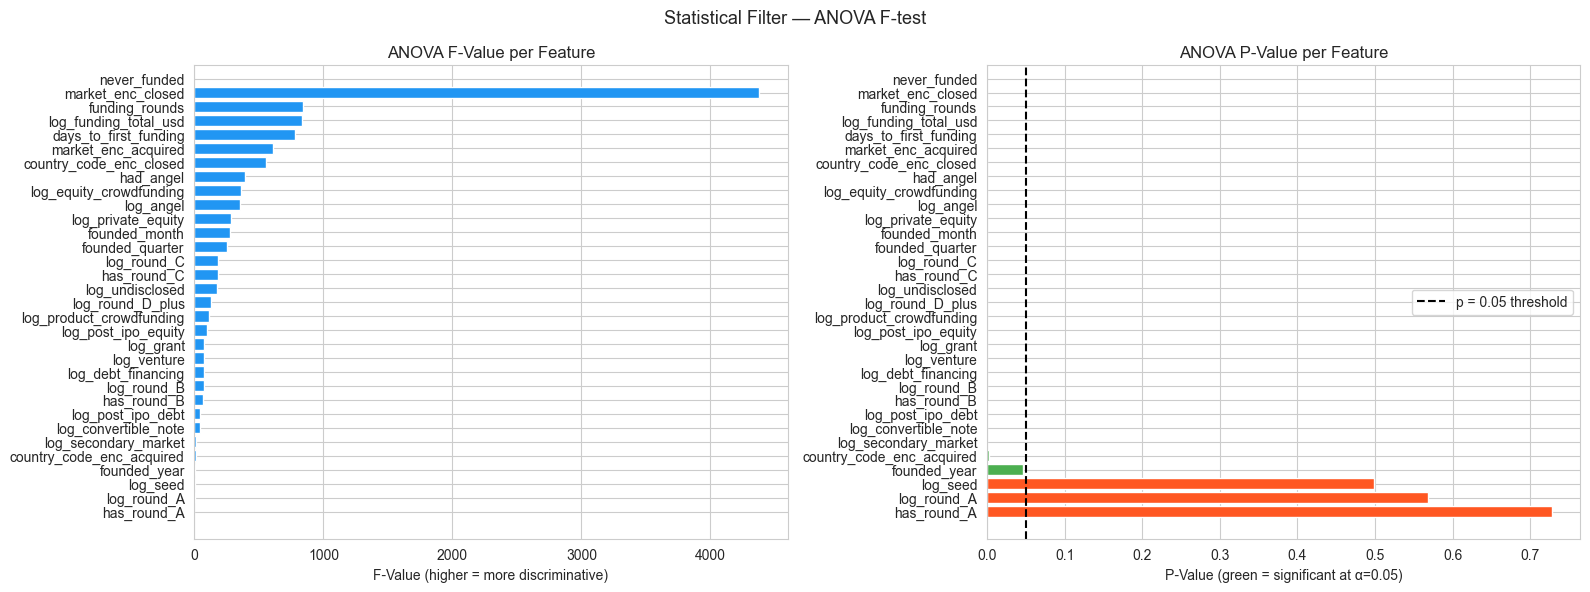


Features significant at α=0.05 (28): ['market_enc_closed', 'funding_rounds', 'log_funding_total_usd', 'days_to_first_funding', 'market_enc_acquired', 'country_code_enc_closed', 'had_angel', 'log_equity_crowdfunding', 'log_angel', 'log_private_equity', 'founded_month', 'founded_quarter', 'log_round_C', 'has_round_C', 'log_undisclosed', 'log_round_D_plus', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_grant', 'log_venture', 'log_debt_financing', 'log_round_B', 'has_round_B', 'log_post_ipo_debt', 'log_convertible_note', 'log_secondary_market', 'country_code_enc_acquired', 'founded_year']


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F-values bar chart
sorted_f = anova_df.sort_values('F-Value', ascending=True)
axes[0].barh(sorted_f['Feature'], sorted_f['F-Value'], color='#2196F3', edgecolor='white')
axes[0].set_title('ANOVA F-Value per Feature')
axes[0].set_xlabel('F-Value (higher = more discriminative)')

# P-values bar chart with significance line
sorted_p = anova_df.sort_values('P-Value', ascending=False)
bar_colors = ['#4CAF50' if p < 0.05 else '#FF5722' for p in sorted_p['P-Value']]
axes[1].barh(sorted_p['Feature'], sorted_p['P-Value'], color=bar_colors, edgecolor='white')
axes[1].axvline(0.05, color='black', linestyle='--', label='p = 0.05 threshold')
axes[1].set_title('ANOVA P-Value per Feature')
axes[1].set_xlabel('P-Value (green = significant at α=0.05)')
axes[1].legend()

plt.suptitle('Statistical Filter — ANOVA F-test', fontsize=13)
plt.tight_layout()
plt.show()

# Features significant at alpha = 0.05
anova_significant = anova_df[anova_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(anova_significant)}): {anova_significant}")

### 3.2 Chi-Squared Test (`chi2`)

Chi-squared tests the independence between each (non-negative) feature and the target.  
- Requires **non-negative** feature values — applicable to our scaled/encoded features that are ≥ 0.
- High χ² statistic → feature and target are strongly associated.

In [7]:
# Shift features to be non-negative for chi2
X_train_nonneg = X_train - X_train.min()

chi2_values, chi2_p = chi2(X_train_nonneg, y_train)

chi2_df = pd.DataFrame({
    'Feature':  X_train.columns,
    'Chi2':     chi2_values,
    'P-Value':  chi2_p
}).sort_values('Chi2', ascending=False).reset_index(drop=True)

print("Chi-Squared test results (sorted by Chi2 statistic):")
display(chi2_df.round(4))

chi2_significant = chi2_df[chi2_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(chi2_significant)}): {chi2_significant}")

Chi-Squared test results (sorted by Chi2 statistic):


,Feature,Chi2,P-Value
0,days_to_first_funding,778781.7278,0.0000
1,log_private_equity,4597.7295,0.0000
2,log_equity_crowdfunding,4177.3525,0.0000
3,log_angel,4128.2856,0.0000
4,log_round_C,2839.3305,0.0000
5,log_undisclosed,2455.5315,0.0000
6,log_round_D_plus,2048.9454,0.0000
7,funding_rounds,1891.4034,0.0000
8,log_post_ipo_equity,1630.4391,0.0000
9,founded_month,1461.3427,0.0000



Features significant at α=0.05 (27): ['days_to_first_funding', 'log_private_equity', 'log_equity_crowdfunding', 'log_angel', 'log_round_C', 'log_undisclosed', 'log_round_D_plus', 'funding_rounds', 'log_post_ipo_equity', 'founded_month', 'log_product_crowdfunding', 'log_grant', 'log_round_B', 'log_debt_financing', 'log_post_ipo_debt', 'log_convertible_note', 'log_venture', 'founded_quarter', 'had_angel', 'log_funding_total_usd', 'market_enc_closed', 'log_secondary_market', 'has_round_C', 'has_round_B', 'market_enc_acquired', 'country_code_enc_closed', 'log_round_A']


In [8]:
# SelectKBest — top K features by ANOVA
K = min(20, len(X_train.columns))
selector_anova = SelectKBest(score_func=f_classif, k=K)
selector_anova.fit(X_train, y_train)

anova_top_k = X_train.columns[selector_anova.get_support()].tolist()
print(f"Top {K} features by ANOVA SelectKBest: {anova_top_k}")

# Binary selection mask for voting (1 if in top K)
anova_selected = selector_anova.get_support().astype(int)

Top 20 features by ANOVA SelectKBest: ['funding_rounds', 'founded_month', 'founded_quarter', 'log_funding_total_usd', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_equity_crowdfunding', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_round_C', 'has_round_C', 'log_round_D_plus', 'had_angel', 'days_to_first_funding', 'market_enc_acquired', 'market_enc_closed', 'country_code_enc_closed']


> **→ Modeling Decision (Filter Methods):** Features with low ANOVA p-values and high chi-squared statistics are strong individual predictors. These filters are fast and model-agnostic, but they don't capture interactions — we use them as one vote in the ensemble.

## 4. Correlation Analysis

Highly correlated features carry redundant information. We remove one from each highly correlated pair to reduce multicollinearity before model-based selection.

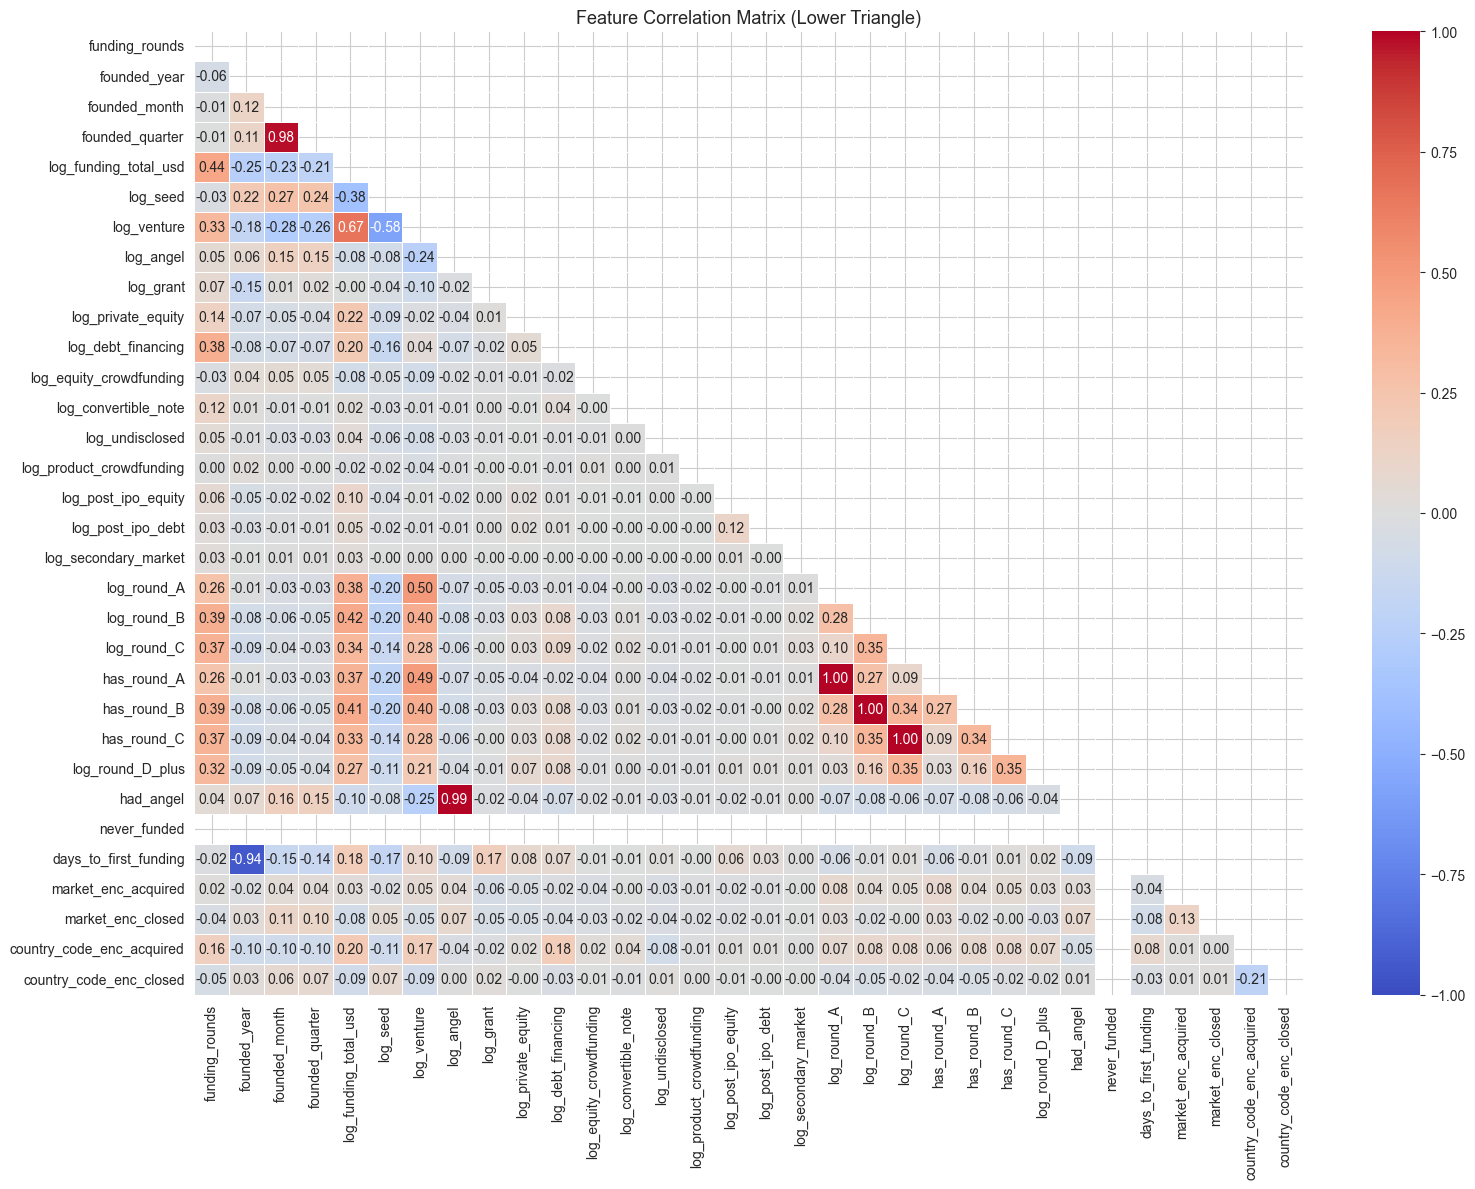

In [9]:
correlation_matrix = X_train.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
CORRELATION_THRESHOLD = 0.75

corr_abs = correlation_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > CORRELATION_THRESHOLD)]

print(f"Correlation threshold: {CORRELATION_THRESHOLD}")
print(f"Original features:   {X_train.shape[1]}")
print(f"Features to drop:    {to_drop_corr}")
print(f"Remaining features:  {X_train.shape[1] - len(to_drop_corr)}")

Correlation threshold: 0.75
Original features:   32
Features to drop:    ['founded_quarter', 'has_round_A', 'has_round_B', 'has_round_C', 'had_angel', 'days_to_first_funding']
Remaining features:  26


> **→ Modeling Decision:** Features with pairwise correlation > 0.7 are candidates for removal. We note which features are collinear and consider dropping the one with the lower ANOVA F-value in the final selection.

## 5. Model-Based Feature Importance (Wrapper Methods)

Wrapper methods evaluate feature importance **through model training**. Each method uses a different mechanism:

| Method | Mechanism |
|--------|-----------|
| **Random Forest** | Mean impurity decrease (Gini) across trees |
| **Gradient Boosting** | Feature usage frequency × gain in all trees |
| **Lasso (L1)** | Shrinks less-useful coefficients to exactly zero |
| **Ridge (L2)** | Shrinks coefficients toward zero — retains all features |
| **Linear SVM (L1)** | Sparse weight vector via L1 penalty |

In [25]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_selected = (rf.feature_importances_ > 0).astype(int)
print(f"Random Forest — features with importance > 0: {rf_selected.sum()}")

Random Forest — features with importance > 0: 31


In [11]:
# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
gb_selected = (gb.feature_importances_ > 0).astype(int)
print(f"Gradient Boosting — features with importance > 0: {gb_selected.sum()}")

Gradient Boosting — features with importance > 0: 26


In [12]:
# --- Lasso (L1) ---
# Lasso performs feature selection by zeroing out less-relevant coefficients.
# Higher alpha = stronger penalty = more features zeroed out.
# Note: multi_class parameter removed — deprecated and auto-handled in sklearn >= 1.2
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                            random_state=RANDOM_STATE, max_iter=2000)
lasso.fit(X_train, y_train)
# For multiclass: a feature is selected if any class has a non-zero coefficient
lasso_selected = (np.abs(lasso.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Lasso (L1 Logistic) — features selected: {lasso_selected.sum()}")

Lasso (L1 Logistic) — features selected: 30


In [13]:
# --- Ridge (L2) ---
# Ridge shrinks coefficients toward zero but rarely sets them exactly to zero.
# Useful for identifying relatively less informative features (very low coefs).
# Note: multi_class parameter removed — deprecated and auto-handled in sklearn >= 1.2
ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0,
                            random_state=RANDOM_STATE, max_iter=2000)
ridge.fit(X_train, y_train)
# Select features whose total absolute coefficient across classes is above median
ridge_coef_sum = np.abs(ridge.coef_).sum(axis=0)
ridge_selected = (ridge_coef_sum > np.median(ridge_coef_sum)).astype(int)
print(f"Ridge (L2 Logistic) — features above median coef magnitude: {ridge_selected.sum()}")

Ridge (L2 Logistic) — features above median coef magnitude: 16


In [14]:
# --- Linear SVM with L1 penalty ---
# LinearSVC with L1 penalty produces sparse weight vectors (feature selection).
svm = LinearSVC(C=0.1, penalty='l1', dual=False, random_state=RANDOM_STATE, max_iter=3000)
svm.fit(X_train, y_train)
svm_selected = (np.abs(svm.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Linear SVM (L1) — features selected: {svm_selected.sum()}")

Linear SVM (L1) — features selected: 30


## 6. Forward Sequential Feature Selection

Forward selection greedily adds the feature that most improves cross-validated performance at each step.  
It captures **feature interactions** that filter methods miss.

In [15]:
# Lightweight base estimator for sequential search
sfs_estimator = RandomForestClassifier(
    n_estimators=30,        # was 100 — enough for selection, not final modeling
    max_depth=8,            # cap depth to speed up each fit
    random_state=RANDOM_STATE,
    n_jobs=-1
)

sfs = SequentialFeatureSelector(
    sfs_estimator,
    n_features_to_select=10,   # was 'auto' — set a fixed cap instead of open-ended
    direction='forward',
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)
sfs.fit(X_train, y_train)

forward_selected = sfs.get_support().astype(int)
forward_features = X_train.columns[sfs.get_support()].tolist()
print(f"Forward Selection — features selected ({len(forward_features)}): {forward_features}")

Forward Selection — features selected (10): ['funding_rounds', 'founded_year', 'log_funding_total_usd', 'log_seed', 'log_venture', 'log_debt_financing', 'days_to_first_funding', 'market_enc_closed', 'country_code_enc_acquired', 'country_code_enc_closed']


## 7. Permutation Importance

Permutation Importance measures how much the model's performance **drops** when a single feature's values are randomly shuffled.  
- A large drop → the model relied heavily on that feature.
- Advantage over built-in importance: works for any fitted model and captures the actual prediction impact.

In [17]:
# Permutation importance — using a small subsample of val for speed
# Full val set with n_repeats=15 is very slow; 500 rows × 5 repeats gives
# a stable enough ranking for a one-vote-in-eight selection signal.
VAL_SAMPLE = min(500, len(X_val))
idx = np.random.default_rng(RANDOM_STATE).choice(len(X_val), VAL_SAMPLE, replace=False)
X_val_pfi = X_val.iloc[idx]
y_val_pfi  = y_val.iloc[idx]

perm = permutation_importance(
    rf, X_val_pfi, y_val_pfi,
    n_repeats=5,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=1              # was -1 — runs in-process, no disk temp files
)

pfi_df = pd.DataFrame({
    'Feature':  X_train.columns,
    'PFI Mean': perm.importances_mean,
    'PFI Std':  perm.importances_std,
}).sort_values('PFI Mean', ascending=False).reset_index(drop=True)

pfi_selected = (perm.importances_mean > 0).astype(int)

print(f"Permutation importance computed on {VAL_SAMPLE} validation samples, 5 repeats.")
display(pfi_df.round(5))

Permutation importance computed on 500 validation samples, 5 repeats.


,Feature,PFI Mean,PFI Std
0,log_venture,0.00853,0.00234
1,log_funding_total_usd,0.00805,0.00277
2,days_to_first_funding,0.00663,0.00153
3,funding_rounds,0.00455,0.00232
4,market_enc_closed,0.00321,0.00333
5,log_seed,0.00268,0.00279
6,founded_year,0.00257,0.00171
7,country_code_enc_closed,0.00210,0.00281
8,market_enc_acquired,0.00195,0.00417
9,log_debt_financing,0.00132,0.00067


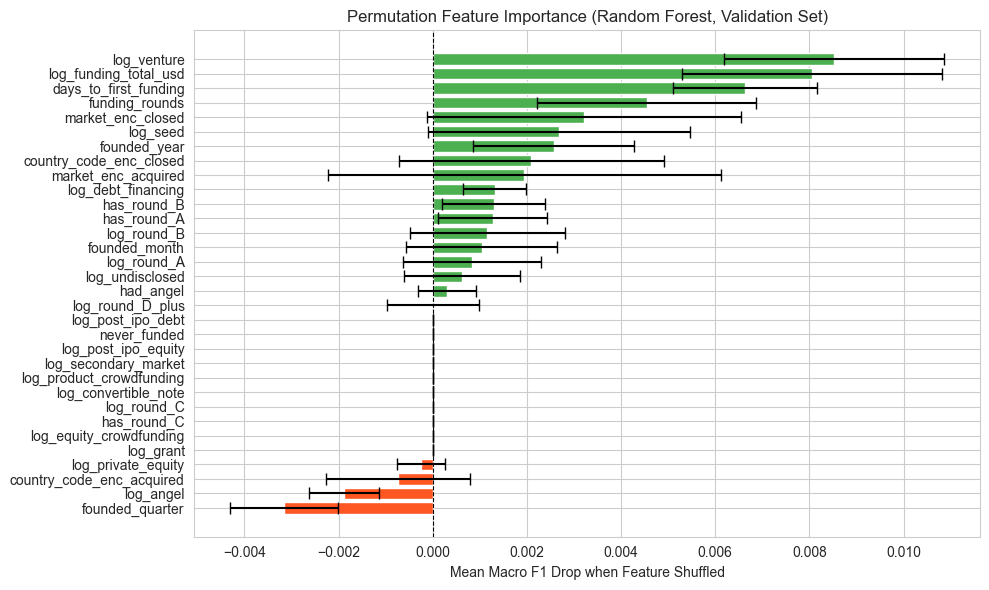

In [18]:
pfi_sorted = pfi_df.sort_values('PFI Mean', ascending=True)
bar_colors = ['#4CAF50' if v > 0 else '#FF5722' for v in pfi_sorted['PFI Mean']]

plt.figure(figsize=(10, 6))
plt.barh(pfi_sorted['Feature'], pfi_sorted['PFI Mean'],
         xerr=pfi_sorted['PFI Std'], color=bar_colors, edgecolor='white', capsize=4)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Permutation Feature Importance (Random Forest, Validation Set)', fontsize=12)
plt.xlabel('Mean Macro F1 Drop when Feature Shuffled')
plt.tight_layout()
plt.show()

## 8. Feature Selection Voting — Aggregated Results

We combine all selection signals into a single vote table.  
Features consistently selected across multiple methods are the most reliable.

In [19]:
selection_df = pd.DataFrame({
    'Feature':       X_train.columns,
    'ANOVA':         anova_selected,
    'Lasso':         lasso_selected,
    'SVM':           svm_selected,
    'GradientBoost': gb_selected,
    'RandomForest':  rf_selected,
    'Ridge':         ridge_selected,
    'Forward':       forward_selected,
    'PFI':           pfi_selected,
})

vote_cols = ['ANOVA', 'Lasso', 'SVM', 'GradientBoost', 'RandomForest', 'Ridge', 'Forward', 'PFI']
selection_df['Sum'] = selection_df[vote_cols].sum(axis=1)
selection_df = selection_df.sort_values('Sum', ascending=False).reset_index(drop=True)

display(selection_df)

,Feature,ANOVA,Lasso,SVM,GradientBoost,RandomForest,Ridge,Forward,PFI,Sum
0,funding_rounds,1,1,1,1,1,1,1,1,8
1,market_enc_closed,1,1,1,1,1,1,1,1,8
2,country_code_enc_closed,1,1,1,1,1,1,1,1,8
3,log_funding_total_usd,1,1,1,1,1,0,1,1,7
4,days_to_first_funding,1,1,1,1,1,0,1,1,7
5,market_enc_acquired,1,1,1,1,1,1,0,1,7
6,log_venture,1,1,1,1,1,0,1,1,7
7,log_undisclosed,1,1,1,1,1,1,0,1,7
8,log_post_ipo_equity,1,1,1,1,1,1,0,0,6
9,log_debt_financing,0,1,1,1,1,0,1,1,6


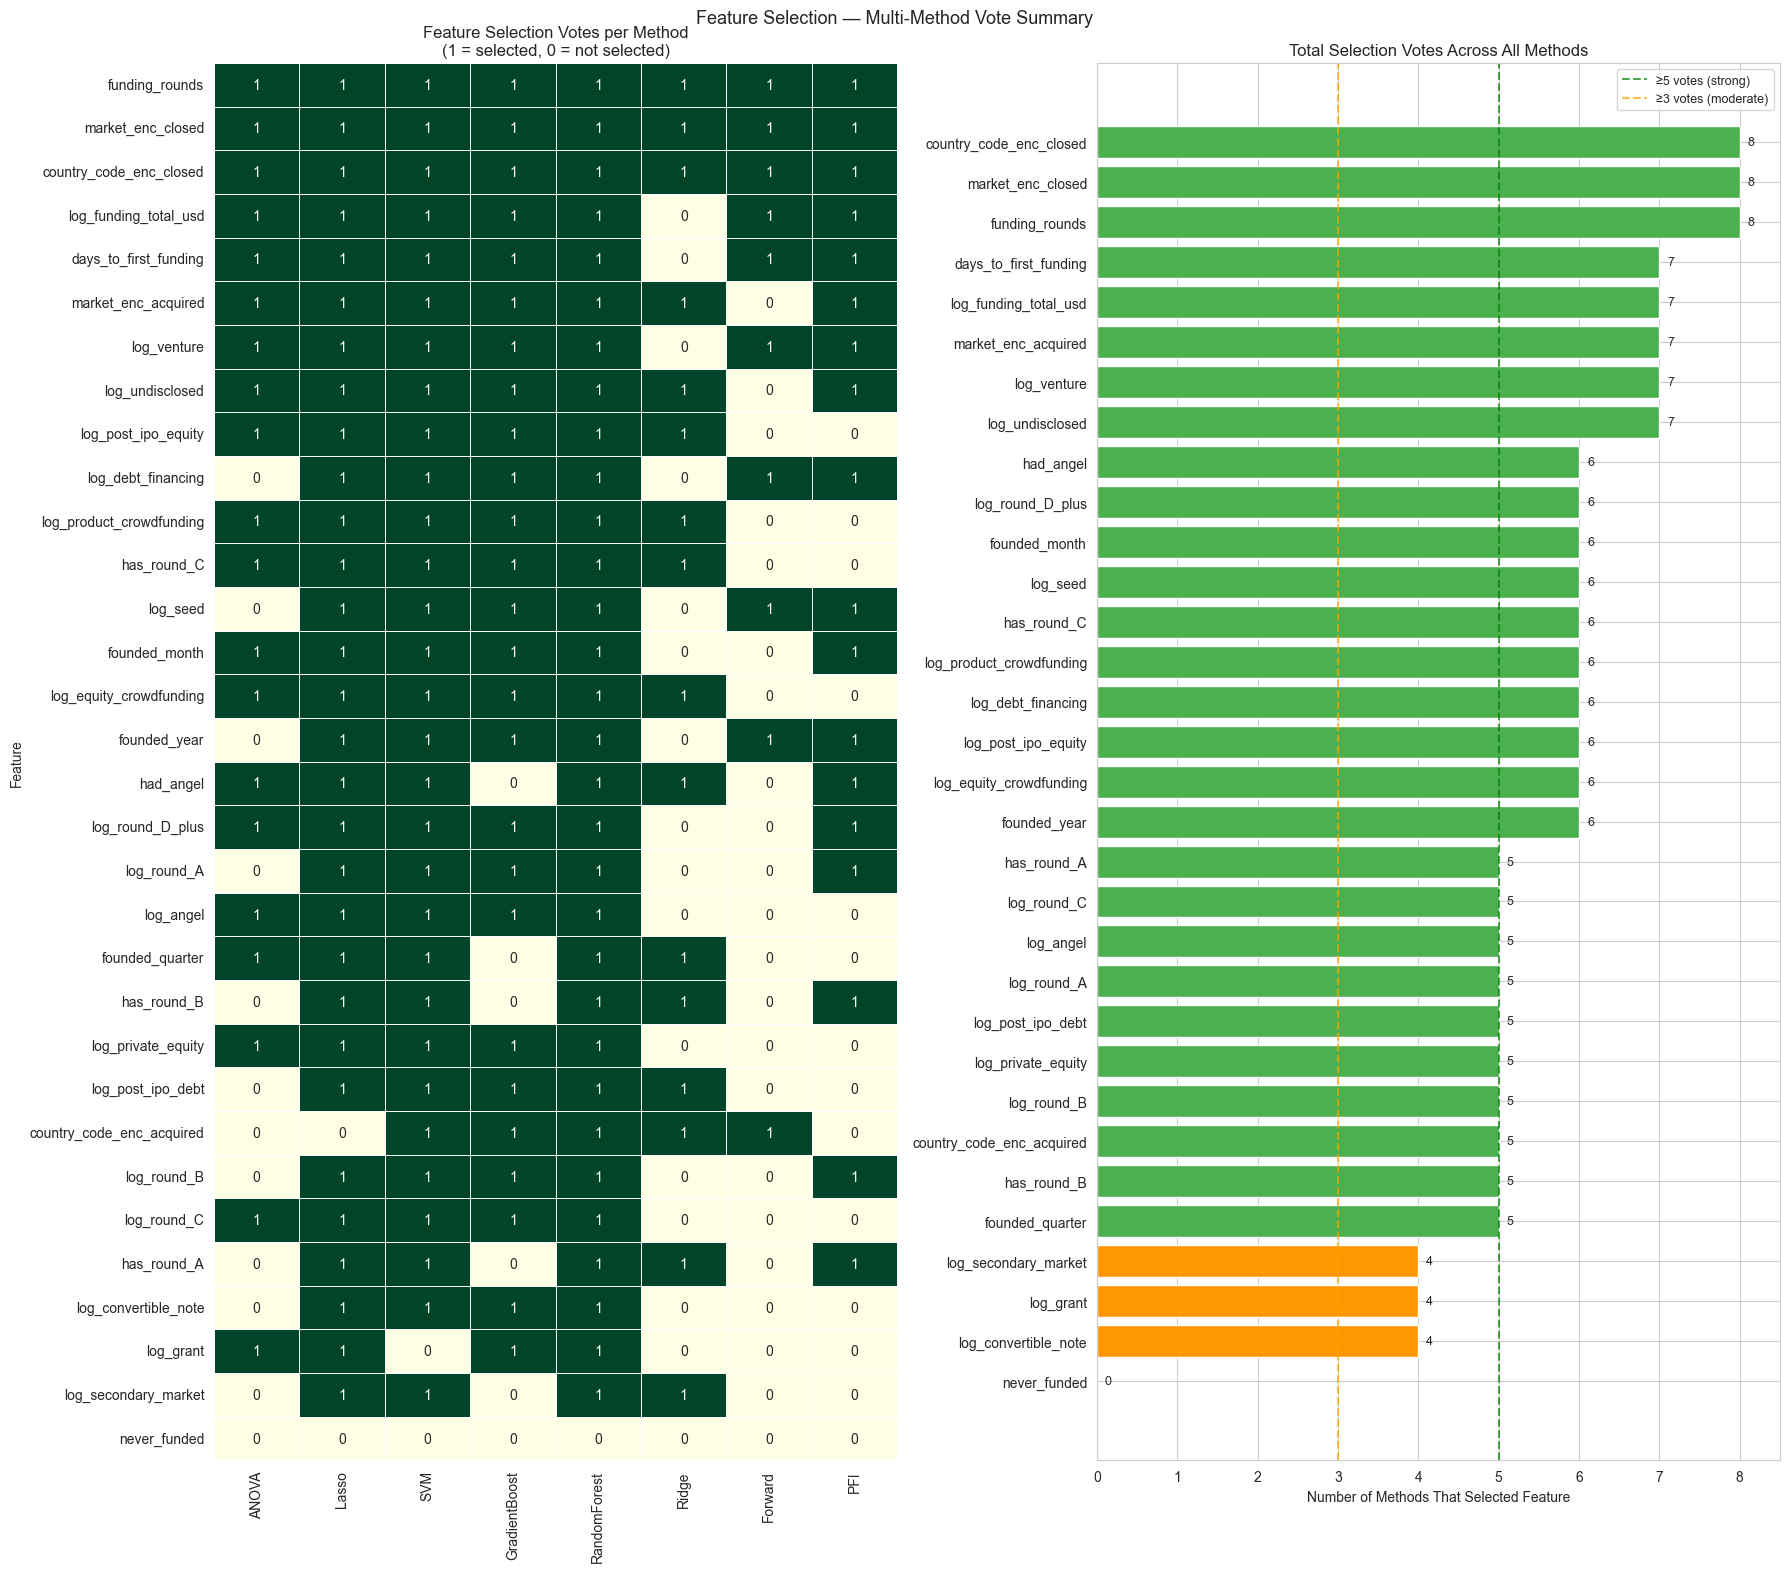

In [20]:
# Heatmap of selection votes
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(X_train.columns) * 0.5)))

# Heatmap
heatmap_data = selection_df.set_index('Feature')[vote_cols]
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGn',
            linewidths=0.5, ax=axes[0], cbar=False,
            vmin=0, vmax=1)
axes[0].set_title('Feature Selection Votes per Method\n(1 = selected, 0 = not selected)')
axes[0].set_xlabel('')

# Bar chart of total votes
sorted_sel = selection_df.sort_values('Sum', ascending=True)
bar_c = ['#4CAF50' if s >= 5 else '#FF9800' if s >= 3 else '#FF5722'
         for s in sorted_sel['Sum']]
axes[1].barh(sorted_sel['Feature'], sorted_sel['Sum'], color=bar_c, edgecolor='white')
axes[1].axvline(5, color='green',  linestyle='--', label='≥5 votes (strong)', alpha=0.7)
axes[1].axvline(3, color='orange', linestyle='--', label='≥3 votes (moderate)', alpha=0.7)
axes[1].set_title('Total Selection Votes Across All Methods')
axes[1].set_xlabel('Number of Methods That Selected Feature')
axes[1].set_xlim(0, len(vote_cols) + 0.5)
axes[1].legend(fontsize=9)
for i, v in enumerate(sorted_sel['Sum']):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.suptitle('Feature Selection — Multi-Method Vote Summary', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# Select features recommended by >= VOTE_THRESHOLD methods
VOTE_THRESHOLD = 5

selected_features = selection_df[selection_df['Sum'] >= VOTE_THRESHOLD]['Feature'].tolist()
all_features      = X_train.columns.tolist()

print(f"Vote threshold: {VOTE_THRESHOLD} / {len(vote_cols)} methods")
print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Dropped features  ({len(all_features) - len(selected_features)}): "
      f"{[f for f in all_features if f not in selected_features]}")

# Build filtered datasets
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

Vote threshold: 5 / 8 methods
Selected features (28): ['funding_rounds', 'market_enc_closed', 'country_code_enc_closed', 'log_funding_total_usd', 'days_to_first_funding', 'market_enc_acquired', 'log_venture', 'log_undisclosed', 'log_post_ipo_equity', 'log_debt_financing', 'log_product_crowdfunding', 'has_round_C', 'log_seed', 'founded_month', 'log_equity_crowdfunding', 'founded_year', 'had_angel', 'log_round_D_plus', 'log_round_A', 'log_angel', 'founded_quarter', 'has_round_B', 'log_private_equity', 'log_post_ipo_debt', 'country_code_enc_acquired', 'log_round_B', 'log_round_C', 'has_round_A']
Dropped features  (4): ['log_grant', 'log_convertible_note', 'log_secondary_market', 'never_funded']


In [26]:
# Apply correlation-based pruning: remove features identified in Section 4 as having
# pairwise correlation > 0.75. Even high-voting features should be dropped if a
# correlated counterpart already captures the same signal.
originally_selected = list(selected_features)
selected_features   = [f for f in selected_features if f not in to_drop_corr]

pruned = [f for f in originally_selected if f in to_drop_corr]
print(f"Correlation pruning removed {len(pruned)} feature(s): {pruned}")
print(f"Final selected features ({len(selected_features)}): {selected_features}")

# Rebuild filtered datasets with the pruned selection
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

Correlation pruning removed 6 feature(s): ['days_to_first_funding', 'has_round_C', 'had_angel', 'founded_quarter', 'has_round_B', 'has_round_A']
Final selected features (22): ['funding_rounds', 'market_enc_closed', 'country_code_enc_closed', 'log_funding_total_usd', 'market_enc_acquired', 'log_venture', 'log_undisclosed', 'log_post_ipo_equity', 'log_debt_financing', 'log_product_crowdfunding', 'log_seed', 'founded_month', 'log_equity_crowdfunding', 'founded_year', 'log_round_D_plus', 'log_round_A', 'log_angel', 'log_private_equity', 'log_post_ipo_debt', 'country_code_enc_acquired', 'log_round_B', 'log_round_C']


> **→ Modeling Decision:** Features selected by ≥ 5 of 8 methods form our **selected feature set**. We will compare models trained on the **full feature set** vs the **selected feature set** to confirm the selection improves or maintains performance.

---
# Part B — Modeling with Regularization

We train five model families with built-in or explicit regularization and compare them on the validation set using **Macro F1** as the primary criterion.

| Model | Regularization mechanism |
|-------|-------------------------|
| Logistic Regression (L2) | Ridge penalty on coefficients |
| Logistic Regression (L1) | Lasso penalty — sparse coefficients |
| Random Forest | Bagging + max_features sub-sampling |
| Gradient Boosting | Shrinkage (learning rate) + subsampling |
| XGBoost | L1/L2 weight regularization + column/row sub-sampling |

### Feature Scaling for Linear Models

Tree models (RF, GB, XGBoost) are invariant to monotonic transformations — scaling doesn't change their splits.
Linear models (LR L1, LR L2) are **not** scale-invariant — large-magnitude features dominate the gradient and produce misleading coefficients without normalization.

We fit a `StandardScaler` on the **training set only** (no leakage) and create separate scaled versions for the full and selected feature sets.

In [27]:
models = {
    'LR (L2)': LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        max_iter=2000, class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'LR (L1)': LogisticRegression(
        penalty='l1', C=0.5, solver='saga',
        max_iter=2000, class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        max_features='sqrt', min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss', verbosity=0,
        random_state=RANDOM_STATE
    ),
}

In [28]:
models = {
    'LR (L2)': LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        max_iter=2000, class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'LR (L1)': LogisticRegression(
        penalty='l1', C=0.5, solver='saga',
        max_iter=2000, class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        max_features='sqrt', min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='mlogloss', verbosity=0,
        random_state=RANDOM_STATE
    ),
}

In [29]:
from sklearn.preprocessing import StandardScaler

LINEAR_MODELS = {"LR (L2)", "LR (L1)"}

# Fit scalers on training data only -- no leakage
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = pd.DataFrame(scaler.transform(X_train),    columns=X_train.columns, index=X_train.index)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),      columns=X_val.columns,   index=X_val.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),     columns=X_test.columns,  index=X_test.index)

scaler_sel = StandardScaler()
scaler_sel.fit(X_train_sel)
X_train_sel_sc = pd.DataFrame(scaler_sel.transform(X_train_sel), columns=X_train_sel.columns, index=X_train_sel.index)
X_val_sel_sc   = pd.DataFrame(scaler_sel.transform(X_val_sel),   columns=X_val_sel.columns,   index=X_val_sel.index)
X_test_sel_sc  = pd.DataFrame(scaler_sel.transform(X_test_sel),  columns=X_test_sel.columns,  index=X_test_sel.index)

print(f"StandardScaler fitted -- linear models will use scaled features, tree models use unscaled.")
print(f"Full: {X_train_sc.shape}  |  Selected: {X_train_sel_sc.shape}")

StandardScaler fitted -- linear models will use scaled features, tree models use unscaled.
Full: (52700, 32)  |  Selected: (52700, 22)


In [33]:
import copy
from sklearn.utils.class_weight import compute_sample_weight

# GB and XGBoost don't support class_weight parameter — use sample_weight in fit() instead
sample_weights      = compute_sample_weight('balanced', y_train)
WEIGHTED_FIT_MODELS = {'Gradient Boosting', 'XGBoost'}

results_full = []
results_sel  = []
fitted_full  = {}
fitted_sel   = {}

for name, model in models.items():
    use_scaled = name in LINEAR_MODELS
    fit_kwargs = {'sample_weight': sample_weights} if name in WEIGHTED_FIT_MODELS else {}

    X_tr     = X_train_sc     if use_scaled else X_train
    X_v      = X_val_sc       if use_scaled else X_val
    X_tr_sel = X_train_sel_sc if use_scaled else X_train_sel
    X_v_sel  = X_val_sel_sc   if use_scaled else X_val_sel

    # --- Full features ---
    m_full = copy.deepcopy(model)
    m_full.fit(X_tr, y_train, **fit_kwargs)
    y_pred_full = m_full.predict(X_v)
    results_full.append(classification_metrics(y_val, y_pred_full, f'{name} [all features]'))
    fitted_full[name] = m_full

    # --- Selected features ---
    m_sel = copy.deepcopy(model)
    m_sel.fit(X_tr_sel, y_train, **fit_kwargs)
    y_pred_sel = m_sel.predict(X_v_sel)
    results_sel.append(classification_metrics(y_val, y_pred_sel, f'{name} [selected features]'))
    fitted_sel[name] = m_sel

    r_f, r_s = results_full[-1], results_sel[-1]
    f0_key = f'F1 {STATUS_NAMES[0]}'
    f1_key = f'F1 {STATUS_NAMES[1]}'
    print(
        f"{name:25s} | "
        f"Acc: {r_f['Accuracy']:.4f}/{r_s['Accuracy']:.4f} | "
        f"Macro F1: {r_f['Macro F1']:.4f}/{r_s['Macro F1']:.4f} | "
        f"Wt F1: {r_f['Weighted F1']:.4f}/{r_s['Weighted F1']:.4f} | "
        # f"{f0_key}: {r_f[f0_key]:.4f}/{r_s[f0_key]:.4f} | "
        f"{f1_key}: {r_f[f1_key]:.4f}/{r_s[f1_key]:.4f}"
        f"  [full/sel]"
    )

LR (L2)                   | Acc: 0.2353/0.2732 | Macro F1: 0.1408/0.1626 | Wt F1: 0.3267/0.3720 | F1 closed: 0.0476/0.0616  [full/sel]
LR (L1)                   | Acc: 0.2351/0.2733 | Macro F1: 0.1407/0.1628 | Wt F1: 0.3264/0.3721 | F1 closed: 0.0476/0.0620  [full/sel]
Random Forest             | Acc: 0.1866/0.2110 | Macro F1: 0.1186/0.1324 | Wt F1: 0.2660/0.2967 | F1 closed: 0.0514/0.0576  [full/sel]
Gradient Boosting         | Acc: 0.1884/0.2155 | Macro F1: 0.1181/0.1338 | Wt F1: 0.2708/0.3043 | F1 closed: 0.0440/0.0529  [full/sel]
XGBoost                   | Acc: 0.2060/0.2350 | Macro F1: 0.1260/0.1422 | Wt F1: 0.2952/0.3298 | F1 closed: 0.0392/0.0483  [full/sel]


## Hyperparameter Tuning — Random Forest & Gradient Boosting

XGBoost regularization was already swept in Section 11. Here we apply a **light grid search** (9 parameter combinations each, 3-fold stratified CV) to find the best `max_depth` / `min_samples_leaf` for RF and `learning_rate` / `max_depth` for GB.

Tuned models are added to the leaderboard so the automatic best-model selection in Section 12 can pick them if they outperform the original fixed-param versions.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Random Forest: tune max_depth and min_samples_leaf (9 combos) ---
rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=300, max_features='sqrt',
                           class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={'max_depth': [8, 12, 16], 'min_samples_leaf': [1, 3, 5]},
    cv=cv3, scoring='f1_macro', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_tuned_f1 = f1_score(y_val, rf_grid.best_estimator_.predict(X_val), average='macro')
print(f"RF  best params : {rf_grid.best_params_}")
print(f"RF  3-fold CV Macro F1: {rf_grid.best_score_:.4f}  |  Val Macro F1: {rf_tuned_f1:.4f}")

# --- Gradient Boosting: tune learning_rate and max_depth (9 combos) ---
gb_grid = GridSearchCV(
    GradientBoostingClassifier(n_estimators=300, subsample=0.8, random_state=RANDOM_STATE),
    param_grid={'learning_rate': [0.03, 0.05, 0.1], 'max_depth': [3, 5, 7]},
    cv=cv3, scoring='f1_macro', n_jobs=-1, verbose=0
)
gb_grid.fit(X_train, y_train)
gb_tuned_f1 = f1_score(y_val, gb_grid.best_estimator_.predict(X_val), average='macro')
print(f"\nGB  best params : {gb_grid.best_params_}")
print(f"GB  3-fold CV Macro F1: {gb_grid.best_score_:.4f}  |  Val Macro F1: {gb_tuned_f1:.4f}")

# Add tuned models to the comparison pool
fitted_full['Random Forest (tuned)']     = rf_grid.best_estimator_
fitted_full['Gradient Boosting (tuned)'] = gb_grid.best_estimator_

tuned_rows = [
    classification_metrics(y_val, rf_grid.best_estimator_.predict(X_val),     'Random Forest (tuned) [all features]'),
    classification_metrics(y_val, gb_grid.best_estimator_.predict(X_val),     'Gradient Boosting (tuned) [all features]'),
]
results_all_df = pd.concat([results_all_df, pd.DataFrame(tuned_rows).set_index('Model')])
print(f"\nUpdated leaderboard (top 5):")
display(results_all_df.sort_values(EVAL_METRIC, ascending=False).head(5).round(4))

In [ ]:
results_all_df = pd.DataFrame(results_full + results_sel).set_index('Model')
display(results_all_df.round(4).sort_values(EVAL_METRIC, ascending=False))

metrics_to_plot = ['Macro F1', f'F1 {STATUS_NAMES[0]}', f'F1 {STATUS_NAMES[1]}']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 6))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_all_df[metric].sort_values(ascending=True)
    bar_cols = ['#2196F3' if 'all' in t else '#4CAF50' for t in vals.index]
    ax.barh(vals.index, vals.values, color=bar_cols, edgecolor='white')
    ax.set_title(metric, fontsize=11)
    ax.set_xlim(0, 1)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='All features'),
                   Patch(facecolor='#4CAF50', label='Selected features')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle('Model Comparison — Validation Set (All vs Selected Features)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
metrics_to_plot = ['Macro F1', 'F1 closed', 'F1 operating', 'F1 acquired']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 6))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_all_df[metric].sort_values(ascending=True)
    bar_cols = ['#2196F3' if 'all' in t else '#4CAF50' for t in vals.index]
    ax.barh(vals.index, vals.values, color=bar_cols, edgecolor='white')
    ax.set_title(metric, fontsize=11)
    ax.set_xlim(0, 1)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='All features'),
                   Patch(facecolor='#4CAF50', label='Selected features')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle('Model Comparison — Validation Set (All vs Selected Features)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Regularization Sensitivity Analysis (XGBoost)

We sweep the XGBoost regularization parameters (`reg_alpha` for L1, `reg_lambda` for L2) to understand their effect on validation Macro F1.

In [ ]:
# Best model by EVAL_METRIC on validation set
best_model_name = results_all_df[EVAL_METRIC].idxmax()
print(f"Best model: {best_model_name}")
print(f"{EVAL_METRIC} (val): {results_all_df.loc[best_model_name, EVAL_METRIC]:.4f}")

# Determine feature set, scaling, and retrieve fitted model
is_selected = 'selected' in best_model_name
base_name   = best_model_name.replace(' [all features]', '').replace(' [selected features]', '')
use_scaled  = base_name in LINEAR_MODELS

best_fitted = fitted_sel.get(base_name) if is_selected else fitted_full.get(base_name)
if best_fitted is None:
    raise ValueError(f"Could not find fitted model for '{base_name}'. Available: {list(fitted_full)}")

if is_selected:
    X_val_best  = X_val_sel_sc  if use_scaled else X_val_sel
    X_test_best = X_test_sel_sc if use_scaled else X_test_sel
else:
    X_val_best  = X_val_sc  if use_scaled else X_val
    X_test_best = X_test_sc if use_scaled else X_test

y_pred_best_val = best_fitted.predict(X_val_best)

> **→ Modeling Decision:** The heatmap reveals the optimal regularization region. We use the best `(reg_alpha, reg_lambda)` pair for our final model.

## 12. Final Model Selection & Confusion Matrices

# Top-3 models side-by-side confusion matrices
top3 = results_all_df['Macro F1'].sort_values(ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (mname, _) in zip(axes, top3.items()):
    _is_sel = 'selected' in mname
    _base   = mname.replace(' [all features]', '').replace(' [selected features]', '')
    _fitted = fitted_sel[_base] if _is_sel else fitted_full[_base]
    _X_val  = X_val_sel if _is_sel else X_val
    _y_pred = _fitted.predict(_X_val)
    _f1     = f1_score(y_val, _y_pred, average='macro')
    plot_confusion_matrix(y_val, _y_pred,
                          title=f"{mname}\nMacro F1 = {_f1:.4f}", ax=ax)

plt.suptitle('Top-3 Models — Confusion Matrices (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
## 13. ROC Curves — All Models (Validation Set)

Single binary ROC curve for each model — no one-vs-rest needed.

## 13. ROC Curves — Best Model (Validation Set)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for mname in results_all_df.index:
    _is_sel = 'selected' in mname
    _base   = mname.replace(' [all features]', '').replace(' [selected features]', '')
    _fitted = fitted_sel.get(_base) if _is_sel else fitted_full.get(_base)
    _X_val  = X_val_sel if _is_sel else X_val

    if _fitted is None:
        continue
    try:
        proba = _fitted.predict_proba(_X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, proba)
        roc_auc = auc(fpr, tpr)
        linestyle = '-' if _is_sel else '--'
        ax.plot(fpr, tpr, linestyle=linestyle,
                label=f"{mname} (AUC={roc_auc:.2f})", linewidth=1.2)
    except AttributeError:
        pass  # LinearSVC has no predict_proba

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title(f'ROC Curves — {STATUS_NAMES[1]} (binary, validation set)', fontsize=12)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])  # (n, 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls_idx, (cls_name, color) in enumerate(zip(STATUS_NAMES, COLORS)):
    ax = axes[cls_idx]

    # Plot all models
    for mname in results_all_df.index:
        _is_sel = 'selected' in mname
        _base   = mname.replace(' [all features]', '').replace(' [selected features]', '')
        _fitted = fitted_sel[_base] if _is_sel else fitted_full[_base]
        _X_val  = X_val_sel if _is_sel else X_val

        try:
            proba = _fitted.predict_proba(_X_val)[:, cls_idx]
            fpr, tpr, _ = roc_curve(y_val_bin[:, cls_idx], proba)
            roc_auc = auc(fpr, tpr)
            linestyle = '-' if _is_sel else '--'
            ax.plot(fpr, tpr, linestyle=linestyle,
                    label=f"{mname} (AUC={roc_auc:.2f})",
                    linewidth=1.2)
        except AttributeError:
            pass  # LinearSVC has no predict_proba

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC — {cls_name} (one-vs-rest)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=6)
    ax.grid(True)

plt.suptitle('ROC Curves per Class — All Models (Validation Set)', fontsize=12)
plt.tight_layout()
plt.show()

## 14. Full Validation Report — Best Model

In [ ]:
print(f"Best model: {best_model_name}")
print(f"Feature set: {'selected' if is_selected else 'all'} "
      f"({len(selected_features) if is_selected else len(all_features)} features)")
print()
print(classification_report(y_val, y_pred_best_val, target_names=STATUS_NAMES))

fig, ax = plt.subplots(figsize=(7, 5))
plot_confusion_matrix(y_val, y_pred_best_val,
                      title=f'{best_model_name}\nConfusion Matrix — Validation Set', ax=ax)
plt.tight_layout()
plt.show()

## 15. Final Evaluation on Test Set

> ⚠️ **Run this cell only once.** The test set is touched here for the first time in this notebook. Using it during model/feature selection would leak information.

In [ ]:
# Side-by-side per-class F1 — validation vs test
val_f1s  = f1_score(y_val,  y_pred_best_val, average=None, labels=[0, 1])
test_f1s = f1_score(y_test, y_pred_test,     average=None, labels=[0, 1])

compare_df = pd.DataFrame({
    'Validation': val_f1s,
    'Test':       test_f1s
}, index=STATUS_NAMES)

compare_df.plot(kind='bar', figsize=(7, 5),
                color=['#2196F3', '#FF9800'], edgecolor='white')
plt.title('Per-Class F1 — Validation vs Test Set')
plt.ylabel('F1 Score')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Split')
plt.tight_layout()
plt.show()

print(compare_df.round(4))

In [ ]:
# Side-by-side per-class F1 — validation vs test
val_f1s  = f1_score(y_val,  y_pred_best_val, average=None, labels=[0, 1, 2])
test_f1s = f1_score(y_test, y_pred_test,     average=None, labels=[0, 1, 2])

compare_df = pd.DataFrame({
    'Validation': val_f1s,
    'Test':       test_f1s
}, index=STATUS_NAMES)

compare_df.plot(kind='bar', figsize=(9, 5),
                color=['#2196F3', '#FF9800'], edgecolor='white')
plt.title('Per-Class F1 — Validation vs Test Set')
plt.ylabel('F1 Score')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Split')
plt.tight_layout()
plt.show()

print(compare_df.round(4))

> **→ Modeling Decision:** A small gap between validation and test Macro F1 is expected and healthy. A large gap would suggest the model is overfitted to the validation set (e.g., via excessive hyperparameter tuning on val). Our regularization and feature selection choices mitigate this risk.

# Display feature importances if the best model supports them
feat_names = selected_features if is_selected else all_features

if hasattr(best_fitted, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    feat_names,
        'Importance': best_fitted.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, max(5, len(feat_names) * 0.4)))
    bars = plt.barh(imp_df['Feature'], imp_df['Importance'], color='#2196F3', edgecolor='white')
    plt.title(f'Feature Importances — {best_model_name}', fontsize=12)
    plt.xlabel('Importance Score')
    for bar, v in zip(bars, imp_df['Importance']):
        plt.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

elif hasattr(best_fitted, 'coef_'):
    # For binary LR/SVM: coef_ is (1, n_features) — flatten to (n_features,)
    coef_arr = np.abs(best_fitted.coef_).sum(axis=0)
    imp_df = pd.DataFrame({
        'Feature':   feat_names,
        '|coef|':    coef_arr
    }).sort_values('|coef|', ascending=True)

    plt.figure(figsize=(10, max(5, len(feat_names) * 0.4)))
    bars = plt.barh(imp_df['Feature'], imp_df['|coef|'], color='#2196F3', edgecolor='white')
    plt.title(f'Coefficient Magnitudes — {best_model_name}', fontsize=12)
    plt.xlabel('|Coefficient|')
    for bar, v in zip(bars, imp_df['|coef|']):
        plt.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
## Summary

### Feature Selection
| Step | Method | Outcome |
|------|--------|---------|
| Filter | ANOVA F-test + Chi-squared | Ranked features by statistical association with binary target |
| Correlation | Pearson correlation matrix | Identified collinear feature pairs |
| Wrapper (importance) | RF, GB, Lasso, Ridge, SVM | Binary selection votes per method |
| Wrapper (sequential) | Forward Selection (RF base, Macro F1) | Interaction-aware selection |
| Post-hoc | Permutation Importance on val set | Confirmed real predictive impact |
| **Aggregated** | **Vote ≥ 5 / 8 methods** | **Final selected feature set** |

### Modeling
| Step | Decision |
|------|----------|
| Problem | Binary: `PROBLEM = "closed"` or `"acquired"` |
| Models tested | LR (L1/L2), Random Forest, Gradient Boosting, XGBoost |
| Feature comparison | All features vs selected features (vote ≥ 5) |
| Selection criterion | **Macro F1 on validation set** |
| Final evaluation | Test set (one-shot, post selection) |

### Input / Output Files
| File | Description |
|------|-------------|
| `data/train_resampled_closed.csv` | Resampled binary training set for `PROBLEM="closed"` (from notebook 06) |
| `data/train_resampled_acquired.csv` | Resampled binary training set for `PROBLEM="acquired"` (from notebook 06) |
| `data/val_processed.csv` | Validation set — unchanged throughout |
| `data/test_processed.csv` | Test set — used only for final evaluation in Section 15 |

## Summary

### Feature Selection
| Step | Method | Outcome |
|------|--------|---------|
| Filter | ANOVA F-test + Chi-squared | Ranked features by statistical association with target |
| Correlation | Pearson correlation matrix | Identified collinear feature pairs |
| Wrapper (importance) | RF, GB, Lasso, Ridge, SVM | Binary selection votes per method |
| Wrapper (sequential) | Forward Selection (RF base, Macro F1) | Interaction-aware selection |
| Post-hoc | Permutation Importance on val set | Confirmed real predictive impact |
| **Aggregated** | **Vote ≥ 5 / 8 methods** | **Final selected feature set** |

### Modeling
| Step | Decision |
|------|----------|
| Models tested | LR (L1/L2), Random Forest, Gradient Boosting, XGBoost |
| Regularization sweep | XGBoost reg_alpha × reg_lambda grid |
| Feature comparison | All features vs selected features (vote ≥ 5) |
| Selection criterion | **Macro F1 on validation set** |
| Final evaluation | Test set (one-shot, post selection) |

### Output Files
| File | Description |
|------|-------------|
| `data/train_resampled.csv` | Resampled training set (from `04_Imbalanced_Data.ipynb`) |
| `data/val_processed.csv` | Validation set — unchanged throughout |
| `data/test_processed.csv` | Test set — used only for final evaluation in Section 15 |